In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
# 1. Load the dataset
df = pd.read_csv('ai_job_impact.csv')


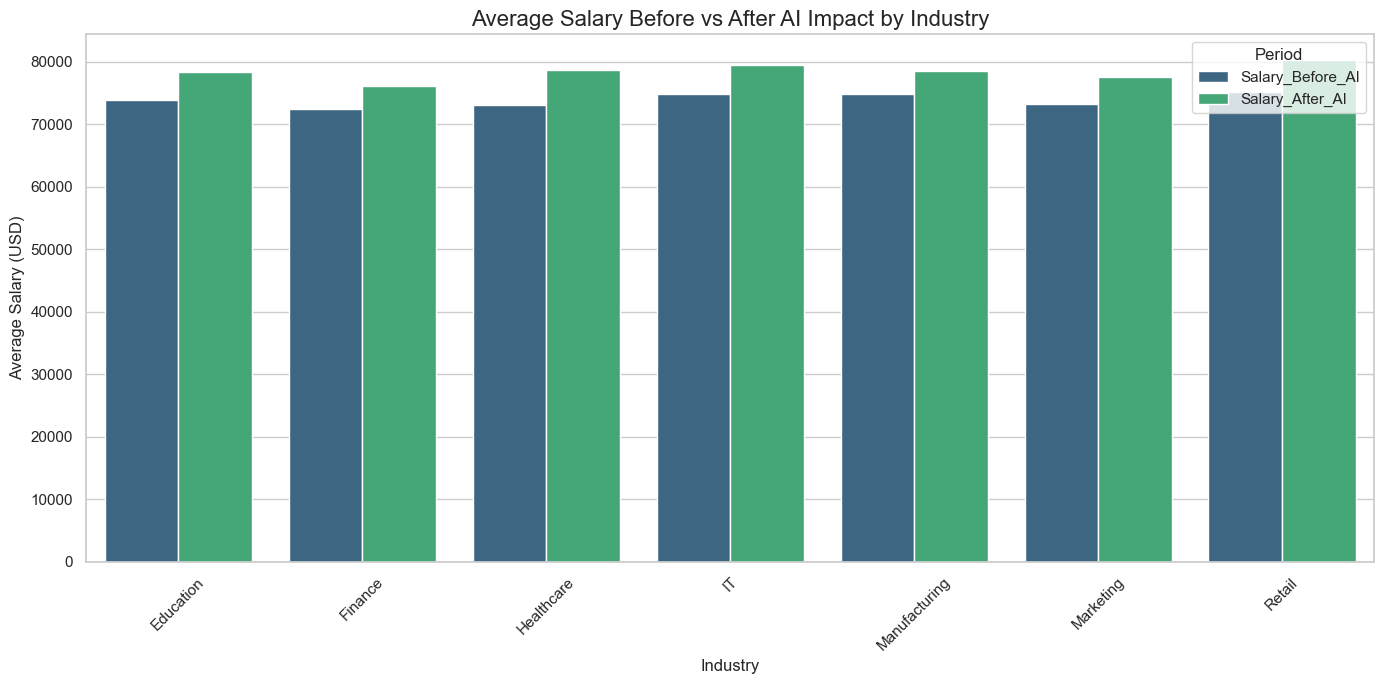

In [6]:
# 2. Salary Impact Analysis: Before vs After AI by Industry
plt.figure(figsize=(14, 7))
# Grouping data to get mean salaries
salary_comp = df.groupby('Industry')[['Salary_Before_AI', 'Salary_After_AI']].mean().reset_index()
# Melting for side-by-side bar chart
salary_melted = salary_comp.melt(id_vars='Industry', var_name='Timeline', value_name='Average Salary')

sns.barplot(data=salary_melted, x='Industry', y='Average Salary', hue='Timeline', palette='viridis')
plt.title('Average Salary Before vs After AI Impact by Industry', fontsize=16)
plt.xlabel('Industry', fontsize=12)
plt.ylabel('Average Salary (USD)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Period')
plt.tight_layout()
plt.savefig('salary_impact_industry.png')

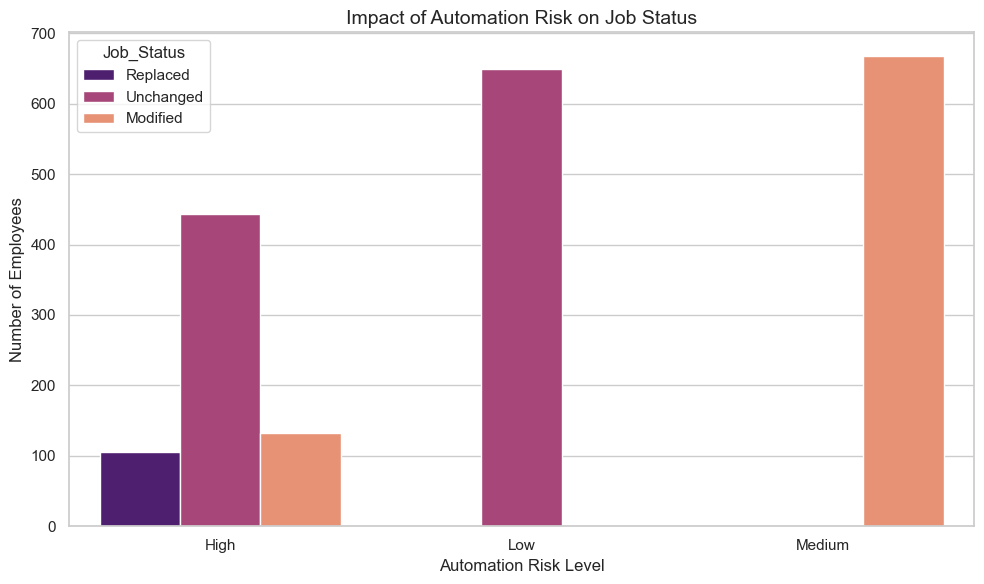

In [7]:
# 3. Job Status Distribution by Automation Risk
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Automation_Risk', hue='Job_Status', palette='magma')
plt.title('Impact of Automation Risk on Job Status', fontsize=14)
plt.xlabel('Automation Risk Level', fontsize=12)
plt.ylabel('Number of Employees', fontsize=12)
plt.tight_layout()
plt.savefig('job_status_risk.png')

C:\Users\Vanshika Verma\AppData\Local\Temp\ipykernel_21640\3669892979.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='AI_Adoption_Level', y='Productivity_Change_%', palette='Set2')


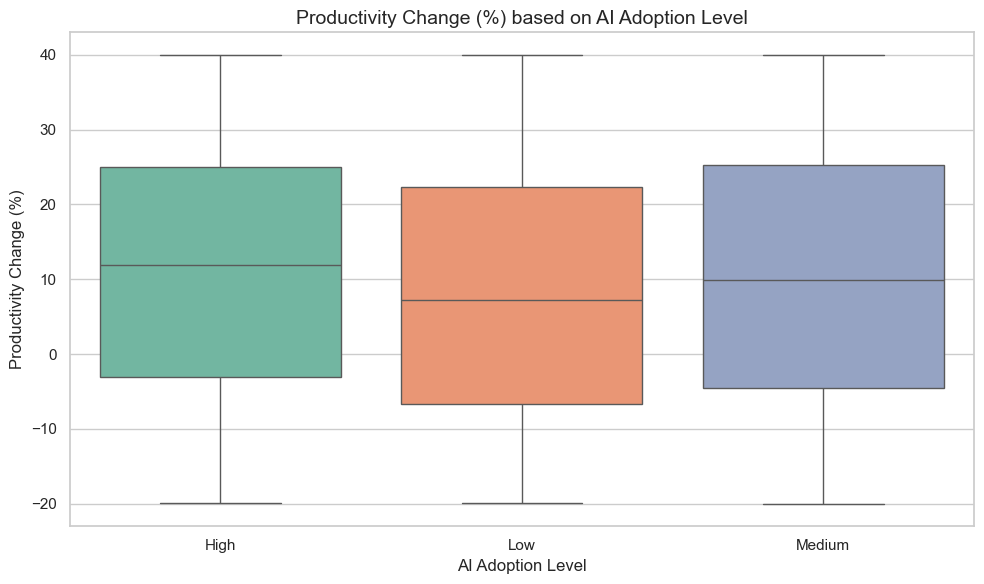

In [8]:
# 4. Productivity Change by AI Adoption Level
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='AI_Adoption_Level', y='Productivity_Change_%', palette='Set2')
plt.title('Productivity Change (%) based on AI Adoption Level', fontsize=14)
plt.xlabel('AI Adoption Level', fontsize=12)
plt.ylabel('Productivity Change (%)', fontsize=12)
plt.tight_layout()
plt.savefig('productivity_adoption.png')


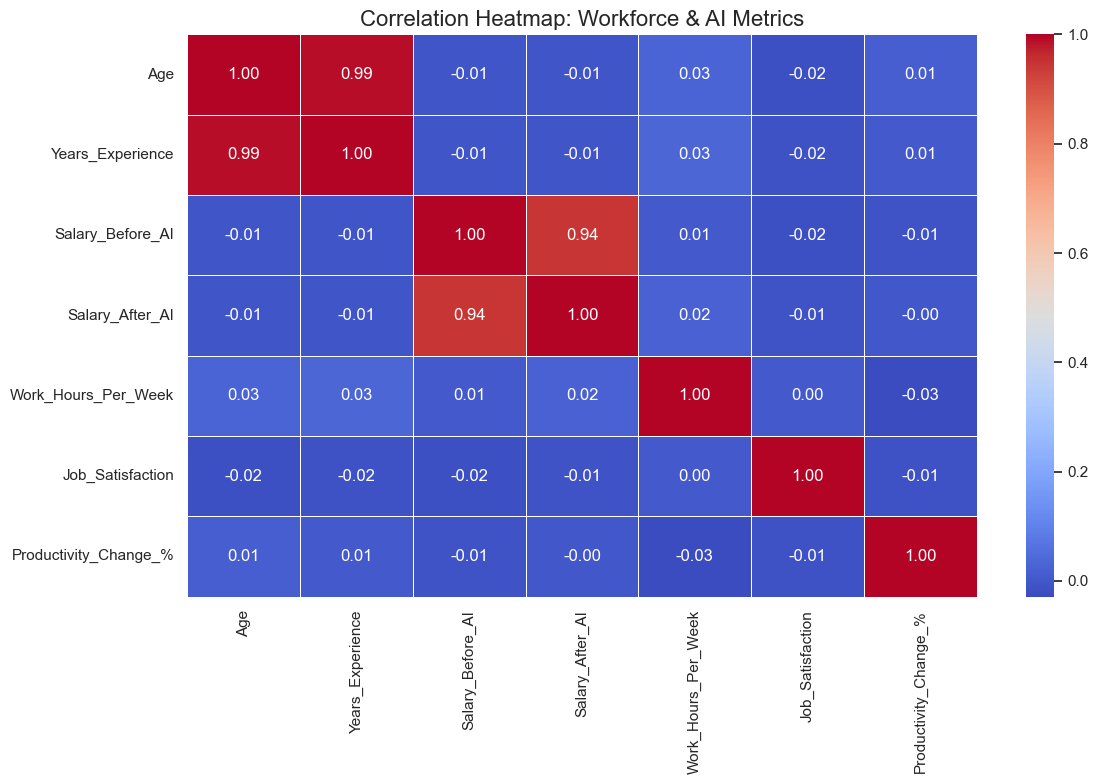

In [9]:
# 5. Correlation Heatmap of Numerical Features
plt.figure(figsize=(12, 8))
numeric_cols = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_cols.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: Workforce & AI Metrics', fontsize=16)
plt.tight_layout()
plt.savefig('correlation_heatmap.png')

C:\Users\Vanshika Verma\AppData\Local\Temp\ipykernel_21640\2323703199.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Remote_Work', y='Job_Satisfaction', inner="quartile", palette='pastel')


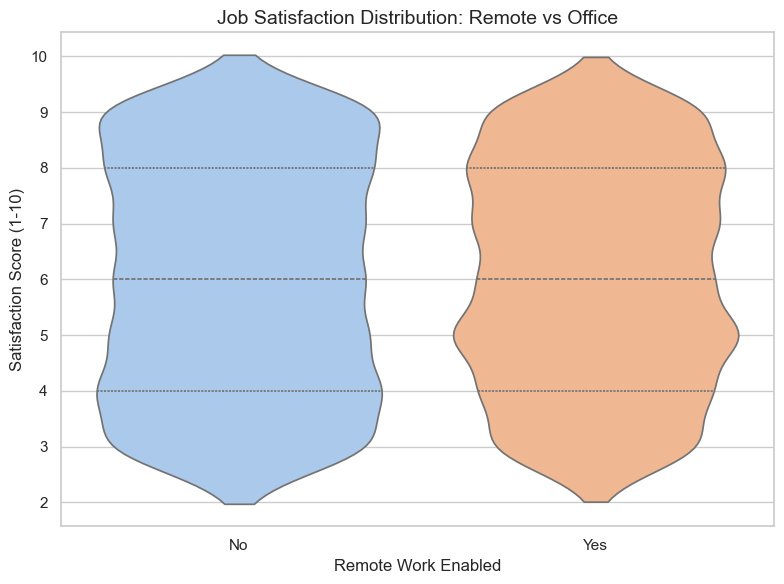

In [10]:
# 6. Job Satisfaction: Remote vs Non-Remote Work
plt.figure(figsize=(8, 6))
sns.violinplot(data=df, x='Remote_Work', y='Job_Satisfaction', inner="quartile", palette='pastel')
plt.title('Job Satisfaction Distribution: Remote vs Office', fontsize=14)
plt.xlabel('Remote Work Enabled', fontsize=12)
plt.ylabel('Satisfaction Score (1-10)', fontsize=12)
plt.tight_layout()
plt.savefig('job_satisfaction_remote.png')

In [11]:
# 7. Generate and save Industry Summary Statistics
summary_stats = df.groupby('Industry').agg({
    'Salary_Before_AI': 'mean',
    'Salary_After_AI': 'mean',
    'Productivity_Change_%': 'mean',
    'Job_Satisfaction': 'mean',
    'Years_Experience': 'mean'
}).round(2).reset_index()

summary_stats.to_csv('industry_summary_stats.csv', index=False)

print("Analysis Complete. All plots and the summary CSV have been generated.")

Analysis Complete. All plots and the summary CSV have been generated.
